# Used Car Price Prediction using Decision Tree Regressor

Goal is predicting used car resale price from year, kms driven, fuel type, company using a Decision Tree Regressor, and understanding how tree depth affects overfitting.

#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np

#### Loading Dataset

In [2]:
df = pd.read_csv("quikr_car.csv")

## Data Understanding

In [3]:
# Display first 10 rows
df.head(10)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
5,Ford EcoSport Titanium 1.5L TDCi,Ford,2015,Ask For Price,"59,000 kms",Diesel
6,Ford Figo,Ford,2012,"1,75,000","41,000 kms",Diesel
7,Hyundai Eon,Hyundai,2013,"1,90,000","25,000 kms",Petrol
8,Ford EcoSport Ambiente 1.5L TDCi,Ford,2016,"8,30,000","24,530 kms",Diesel
9,Maruti Suzuki Alto K10 VXi AMT,Maruti,2015,"2,50,000","60,000 kms",Petrol


In [4]:
df.tail(10)

,name,company,year,Price,kms_driven,fuel_type
882,Maruti Suzuki Alto 800 Select Variant,Maruti,2015,Ask For Price,"70,000 kms",Petrol
883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,"2,70,000","50,000 kms",Petrol
884,tata zest 2017 f,tata,sale,"4,50,000",NaN,NaN
885,Tata Indica V2 DLE BS III,Tata,2009,"1,10,000","30,000 kms",Diesel
886,Toyota Corolla Altis,Toyota,2009,"3,00,000","1,32,000 kms",Petrol
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,"1,60,000",Petrol,NaN


In [5]:
# Rows x Columns
df.shape

(892, 6)

In [6]:
df.columns

Index(['name', 'company', 'year', 'Price', 'kms_driven', 'fuel_type'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        892 non-null    str  
 1   company     892 non-null    str  
 2   year        892 non-null    str  
 3   Price       892 non-null    str  
 4   kms_driven  840 non-null    str  
 5   fuel_type   837 non-null    str  
dtypes: str(6)
memory usage: 41.9 KB


In [8]:
df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(94)

## Data Preprocessing

In [10]:
df['year'].unique()

<StringArray>
['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016', '2010',
 '2017', '2008', '2011', '2019', '2009', '2005', '2000',  '...', '150k',
 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs', 'sale', '1995', 'ara)',
 '2002', 'SELL', '2001', 'tion', 'odel', '2 bs', 'arry',  'Eon', 'o...',
 'ture',  'emi',  'car', 'able',  'no.', 'd...', 'SALE', 'digo', 'sell',
 'd Ex', 'n...', 'e...', 'D...', ', Ac', 'go .', 'k...', 'o c4', 'zire',
 'cent', 'Sumo',  'cab', 't xe',  'EV2', 'r...', 'zest']
Length: 61, dtype: str

In [11]:
df = df[df['year'].str.isnumeric()] # some rows have junk like 'TOUR' instead of a real year

In [12]:
df['year'] = df['year'].astype(int)

In [13]:
df = df.reset_index(drop=True)

In [14]:
df['Price'].unique()

<StringArray>
[       '80,000',      '4,25,000', 'Ask For Price',      '3,25,000',
      '5,75,000',      '1,75,000',      '1,90,000',      '8,30,000',
      '2,50,000',      '1,82,000',
 ...
        '42,000',      '1,89,000',      '1,62,000',        '35,999',
     '29,00,000',        '39,999',        '50,500',      '5,10,000',
      '8,60,000',      '5,00,001']
Length: 273, dtype: str

In [15]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [16]:
df = df[df['Price'] != 'Ask For Price'] # Can't be converted to Numbers

In [17]:
df['Price'] = df['Price'].str.replace(',', '').astype(int)

In [18]:
df['Price'].dtype

dtype('int64')

In [19]:
df['Price'].describe() 

count    8.190000e+02
mean     4.109604e+05
std      4.744866e+05
min      3.000000e+04
25%      1.750000e+05
50%      2.999990e+05
75%      4.900000e+05
max      8.500003e+06
Name: Price, dtype: float64

In [20]:
df = df.reset_index(drop=True)

In [21]:
df['kms_driven'].unique()[:20]

<StringArray>
['45,000 kms',     '40 kms', '28,000 kms', '36,000 kms', '41,000 kms',
 '25,000 kms', '24,530 kms', '60,000 kms', '30,000 kms', '32,000 kms',
 '48,660 kms',  '4,000 kms', '16,934 kms', '43,000 kms', '35,550 kms',
 '39,522 kms', '39,000 kms', '55,000 kms', '72,000 kms', '15,975 kms']
Length: 20, dtype: str

In [22]:
# striping "kms" text and commas, keeping only rows that are now valid numbers
df['kms_driven'] = df['kms_driven'].str.split(' ').str.get(0).str.replace(',', '') 
df = df[df['kms_driven'].str.isnumeric()]
df['kms_driven'] = df['kms_driven'].astype(int)

In [23]:
df['fuel_type'].isnull().sum()

np.int64(1)

In [24]:
df = df[~df['fuel_type'].isna()]

In [25]:
df['name'].nunique()

463

In [26]:
# trimming to first 3 words groups similar cars
df['name'] = df['name'].str.split(' ').str.slice(0,3).str.join(' ')

In [27]:
df['Price'].describe()

count    8.160000e+02
mean     4.117176e+05
std      4.751844e+05
min      3.000000e+04
25%      1.750000e+05
50%      2.999990e+05
75%      4.912500e+05
max      8.500003e+06
Name: Price, dtype: float64

In [28]:
df = df[df['Price'] < 6000000]

In [29]:
df.duplicated().sum()
df = df.drop_duplicates()

In [30]:
df = df.reset_index(drop=True)
df.shape   # sanity check: how many rows survived cleaning?

(719, 6)

## Exploratary Data Analysis

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

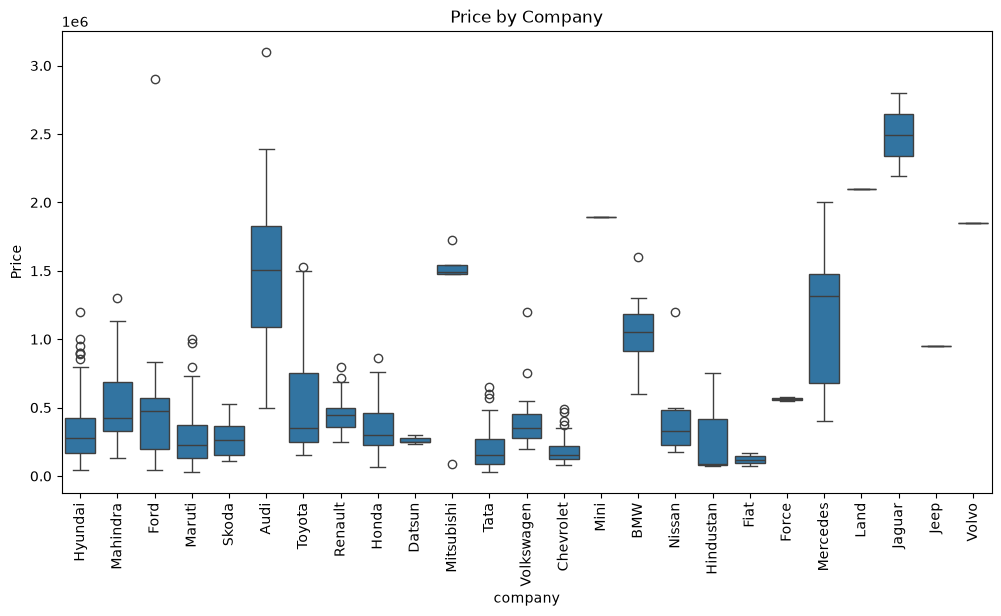

In [32]:
plt.figure(figsize=(12,6))
sns.boxplot(x='company', y='Price', data=df)
plt.xticks(rotation=90)
plt.title('Price by Company')
plt.show()

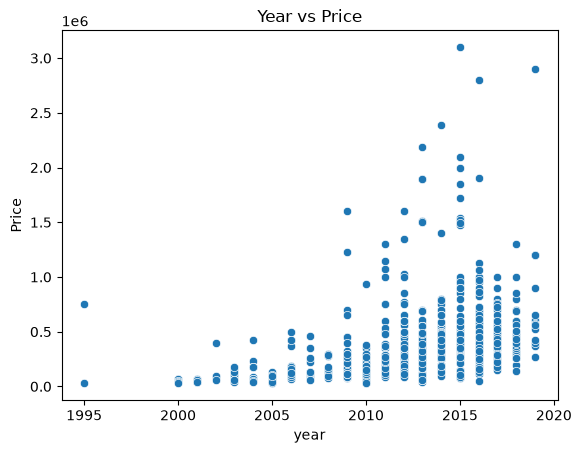

In [33]:
sns.scatterplot(x='year', y='Price', data=df)
plt.title('Year vs Price')
plt.show()

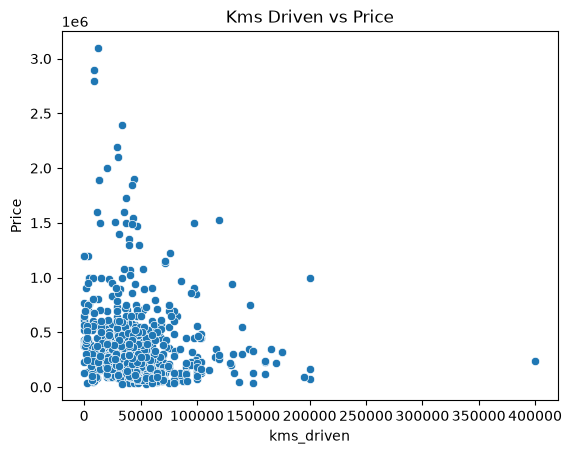

In [34]:
sns.scatterplot(x='kms_driven', y='Price', data=df)
plt.title('Kms Driven vs Price')
plt.show()

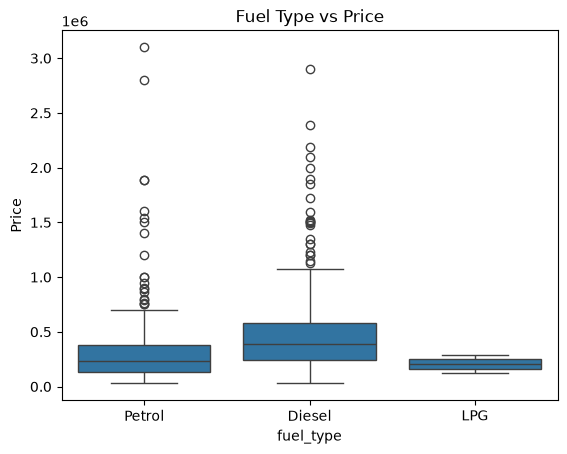

In [35]:
sns.boxplot(x='fuel_type', y='Price', data=df)
plt.title('Fuel Type vs Price')
plt.show()

## Feature Encoding

In [36]:
# convert text columns (name, company, fuel_type) to numbers
categorical_cols =  ['name', 'company', 'fuel_type']

In [37]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

onehotencoder = OneHotEncoder(handle_unknown='ignore')
# handle_unknown='ignore' avoids errors on unseen categories in test data

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
    ("OneHotEncoder",onehotencoder,categorical_cols)],
    remainder='passthrough'  # Remainder='passthrough' keeps the other remaining columns as it is.(Inclusive)
                             # Default removes the remaining columns
)

#### Train-Test-Split

In [38]:
X = df.drop(['Price'], axis=1)
y = df['Price']

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42
)

## Model Building

In [41]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [42]:
depths = range(2, 16)
train_scores = []
test_scores = []

for d in depths:
    pipeline = make_pipeline(preprocessor, DecisionTreeRegressor(max_depth=d, random_state=42))
    pipeline.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, pipeline.predict(X_train)))
    test_scores.append(r2_score(y_test, pipeline.predict(X_test)))

for d, tr, te in zip(depths, train_scores, test_scores):
    print(f"max_depth={d:2d}  train_R2={tr:.3f}  test_R2={te:.3f}")

max_depth= 2  train_R2=0.291  test_R2=0.211
max_depth= 3  train_R2=0.414  test_R2=0.202
max_depth= 4  train_R2=0.504  test_R2=0.178
max_depth= 5  train_R2=0.568  test_R2=0.214
max_depth= 6  train_R2=0.619  test_R2=0.413
max_depth= 7  train_R2=0.662  test_R2=0.400
max_depth= 8  train_R2=0.697  test_R2=0.400
max_depth= 9  train_R2=0.733  test_R2=0.496
max_depth=10  train_R2=0.756  test_R2=0.506
max_depth=11  train_R2=0.782  test_R2=0.498
max_depth=12  train_R2=0.808  test_R2=0.354
max_depth=13  train_R2=0.822  test_R2=0.347
max_depth=14  train_R2=0.839  test_R2=0.383
max_depth=15  train_R2=0.859  test_R2=0.632


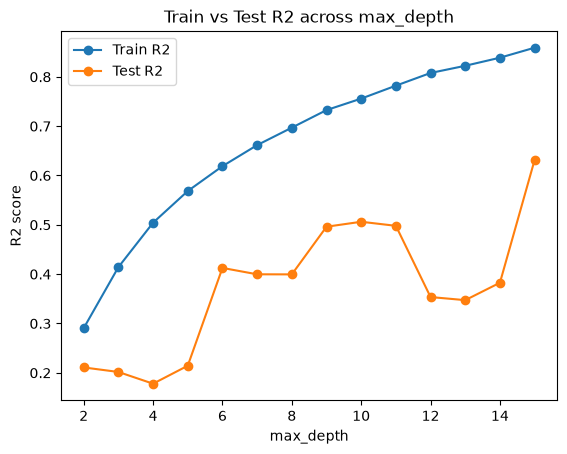

In [43]:
plt.plot(depths, train_scores, marker='o', label='Train R2')
plt.plot(depths, test_scores, marker='o', label='Test R2')
plt.xlabel('max_depth')
plt.ylabel('R2 score')
plt.legend()
plt.title('Train vs Test R2 across max_depth')
plt.show()

### Final Model

In [44]:
final_model = make_pipeline(preprocessor, DecisionTreeRegressor(max_depth=10, random_state=42)) # max_depth=10 chosen: test R2 peaked here in the sweep before overfitting increased
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['name','company','year','kms_driven','fuel_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [45]:
final_preds = final_model.predict(X_test)

## Evaluation Metrics

In [46]:
r2 = r2_score(y_test, final_preds)
mae = mean_absolute_error(y_test, final_preds)
rmse = mean_squared_error(y_test, final_preds) ** 0.5

print(f"R2 score : {r2:.3f}")
print(f"MAE      : Rs {mae:,.0f}")
print(f"RMSE     : Rs {rmse:,.0f}")

R2 score : 0.506
MAE      : Rs 175,157
RMSE     : Rs 280,311


## Actual vs Predicted

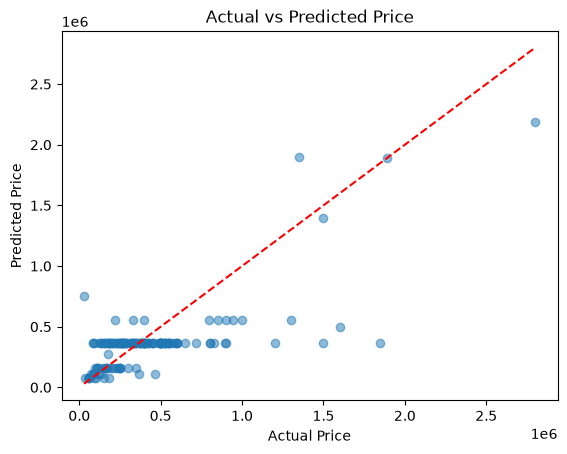

In [47]:
plt.scatter(y_test, final_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

## Conclusion

This project cleaned raw, messy scraped car listing data and trained a 
Decision Tree Regressor to predict resale price. After cleaning, 719 rows 
remained out of the original 892. Hyperparameter tuning was done manually 
(max_depth only, since GridSearchCV hasn't been covered yet), sweeping 
depths 2-15 and picking 10 where test R² peaked.

The final model achieved:
- R²    : 0.506
- MAE   : Rs 175,157
- RMSE  : Rs 280,311

Limitations: only 719-ish rows remained after cleaning, which is small for 
25+ car brands. Only max_depth was tuned - other hyperparameters like 
min_samples_leaf or criterion were left at default since grid search 
hasn't been learned yet.